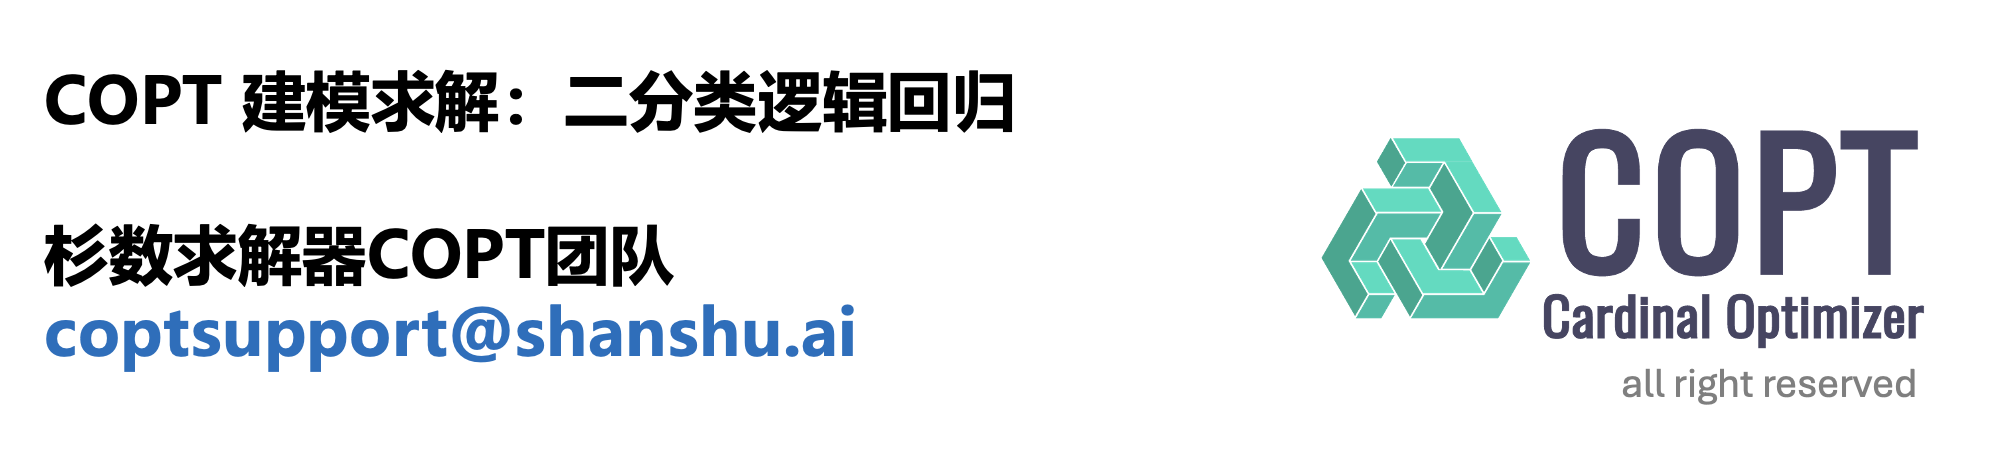

> **在线运行说明。** 下一格安装 `coptpy`。内置的免费许可有规模上限，但足够跑通本案例。然后执行「运行所有」。


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy matplotlib numpy


In [ ]:
# 中文字体：运行环境通常没有 CJK 字体，注册随仓库分发的思源黑体子集
import os, urllib.request, matplotlib, matplotlib.font_manager as fm
FONT = 'NotoSansCJKsc-Regular-subset.otf'
CAND = [FONT, os.path.join('..', 'assets', FONT), os.path.join('..', '..', 'assets', FONT),
        os.path.join('assets', FONT)]
URLS = [
    'https://gitee.com/tztgracious/copt-colab-cases/raw/main/assets/' + FONT,
    'https://raw.githubusercontent.com/tztgracious/copt-colab-cases/main/assets/' + FONT,
]
path = next((p for p in CAND if os.path.exists(p)), None)
if path is None:
    for u in URLS:
        try:
            urllib.request.urlretrieve(u, FONT); path = FONT; break
        except Exception:
            continue
if path:
    fm.fontManager.addfont(path)
    matplotlib.rcParams['font.sans-serif'] = [fm.FontProperties(fname=path).get_name()]
    matplotlib.rcParams['axes.unicode_minus'] = False
    print('中文字体已就绪:', matplotlib.rcParams['font.sans-serif'][0])
else:
    print('未能加载中文字体，图表中的中文可能显示为方块')

# 二分类逻辑回归问题代码实现

## 使用COPT建模求解二分类逻辑回归问题的步骤

在Python中调用COPT对二分类逻辑回归问题进行建模和求解的基本步骤如下：

1. 导入COPT-Python接口库 `coptpy` 

2. 添加/导入模型**数据**样本特征和类别编号

3. 创建**COPT求解环境**和**COPT求解模型**

4. 构建模型，依次添加**模型三要素**
- 添加**决策变量**：可以通过批量添加，或通过构造`MVar`类矩阵变量的建模方式高效添加多维变量
- 设置**目标函数**：可以通过使用`nl`命名空间构建非线性表达式
- 添加**约束条件**：对于构成较为复杂的表达式，使用 `LinExpr`（线性表达式）和 `QuadExpr`（二次表达式）类先构造实例化对象，再逐次添加表达式项目；
- （添加**指数锥**：`Model.addExpCone([x,y,z], COPT.EXPCONE_PRIMAL)` 需要标准型（输入变量为单个元素）；`Model.addAffineCone()` 可接收仿射锥形式输入， 先通过 `AffineConeBuilder` 类构造实例化的仿射锥对象，以添加较为复杂的指数锥）
5. **求解**

6. 查看、分析**结果**

<font color=#0000FF>
<b>注意：使用COPT的仿射锥和指数锥模块，要求COPT为7.2.4及以上版本。</b>
</font>

## 导入COPT-Python接口库

In [1]:
import coptpy as cp
from coptpy import COPT,nl

## 导入数据

`point_data`是已知的35个数据点，其中`point_data`的键是点的序号，而键对应的值是点的特征`[feature1,feature2]`和分类编号`class`。

例如`3:[[4.2, 0.4], 0]`代表点的序号为`3`，特征为`[4.2, 0.4]`，类别为`0`。

In [3]:
# point: [[feature1, feature2], class]
point_data = {
    1: [[0.2, 1.8], 0],
    2: [[2.5, 1.7], 0],
    3: [[4.2, 0.4], 0],
    4: [[0.9, 3.7], 0],
    5: [[0.3, 2.3], 0],
    6: [[1.0, 2.9], 0],
    7: [[0.4, 4.0], 0],
    8: [[1.2, 1.6], 0],
    9: [[2.95, 1.05], 0],
    10: [[4.0, 5.0], 1],
    11: [[1.8, 3.9], 1],
    12: [[1.2, 5.1], 1],
    13: [[4.1, 1.8], 1],
    14: [[3.9, 5.2], 1],
    15: [[3.3, 5.0], 1],
    16: [[3.0, 4.7], 1],
    17: [[2.1, 4.8], 1],
    18: [[3.5, 2.3], 1],
    19: [[0.85, 4.95], 1],
    20: [[1.5, 3.0], 0],
    21: [[1.9, 2.8], 0],
    22: [[2.7, 2.1], 0],
    23: [[1.0, 0.7], 0],
    24: [[1.4, 3.6], 0],
    25: [[3.0, 4.0], 1],
    26: [[4.2, 3.2], 1],
    27: [[2.9, 3.8], 1],
    28: [[3.0, 5.1], 1],
    29: [[4.0, 3.5], 1],
    30: [[0.8, 4,0], 1],
    31: [[3.5, 1.0], 1],
    32: [[1.5, 4.2], 0],
    33: [[2.5, 4.0], 0],
    34: [[3.7, 1.9], 0],
    35: [[1.0, 2.0], 0],
}

我们通过COPT的`multidict(data)`方法将`point_data`中点的`point_index`和`point_feature`和`point_class`分别取出，以方便绘图与之后的处理。

In [5]:
point_index, point_feature, point_class = cp.multidict(point_data)

print('point_index:', point_index)
print('\npoint_feature:', point_feature)
print('\npoint_class:', point_class)

point_index: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]

point_feature: {1: [0.2, 1.8], 2: [2.5, 1.7], 3: [4.2, 0.4], 4: [0.9, 3.7], 5: [0.3, 2.3], 6: [1.0, 2.9], 7: [0.4, 4.0], 8: [1.2, 1.6], 9: [2.95, 1.05], 10: [4.0, 5.0], 11: [1.8, 3.9], 12: [1.2, 5.1], 13: [4.1, 1.8], 14: [3.9, 5.2], 15: [3.3, 5.0], 16: [3.0, 4.7], 17: [2.1, 4.8], 18: [3.5, 2.3], 19: [0.85, 4.95], 20: [1.5, 3.0], 21: [1.9, 2.8], 22: [2.7, 2.1], 23: [1.0, 0.7], 24: [1.4, 3.6], 25: [3.0, 4.0], 26: [4.2, 3.2], 27: [2.9, 3.8], 28: [3.0, 5.1], 29: [4.0, 3.5], 30: [0.8, 4, 0], 31: [3.5, 1.0], 32: [1.5, 4.2], 33: [2.5, 4.0], 34: [3.7, 1.9], 35: [1.0, 2.0]}

point_class: {1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0, 10: 1, 11: 1, 12: 1, 13: 1, 14: 1, 15: 1, 16: 1, 17: 1, 18: 1, 19: 1, 20: 0, 21: 0, 22: 0, 23: 0, 24: 0, 25: 1, 26: 1, 27: 1, 28: 1, 29: 1, 30: 1, 31: 1, 32: 0, 33: 0, 34: 0, 35: 0}


绘制数据点图像。

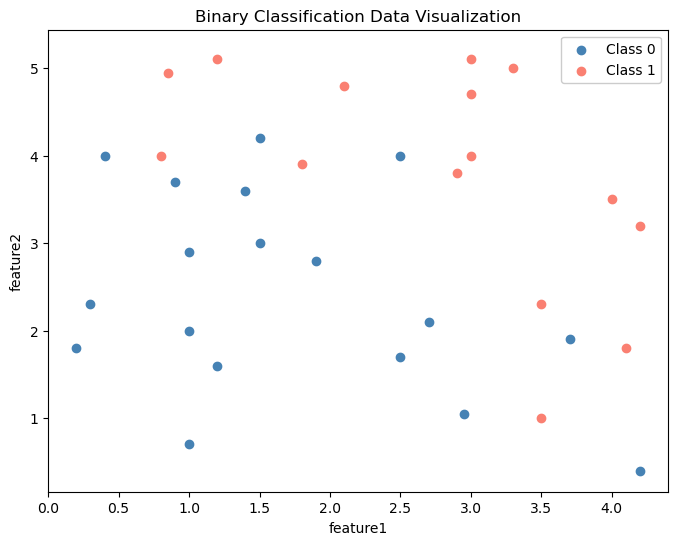

In [7]:
import matplotlib.pyplot as plt

point_class0 = [point_feature[index] for index in point_index if point_class[index] == 0]  # 类别 0
point_class1 = [point_feature[index] for index in point_index if point_class[index] == 1]  # 类别 1

plt.figure(figsize=(8, 6))
plt.scatter([x[0] for x in point_class0], [x[1] for x in point_class0], c='steelblue', label='Class 0')
plt.scatter([x[0] for x in point_class1], [x[1] for x in point_class1], c='salmon', label='Class 1')

plt.xlabel('feature1')
plt.ylabel('feature2')
plt.title('Binary Classification Data Visualization')
plt.legend(loc='upper right', facecolor='white', framealpha=1.0)
plt.show()

## 问题一：非线性模块求解
我们直接求解无约束的非线性问题。
## 创建模型
创建名为`binary_classification_q1`的模型`model_1`。

In [9]:
env = cp.Envr()
model_1 = env.createModel("binary_classification_q1")

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



添加模型正则化参数`lamda`（即$\lambda$）和样本数量`n_samples`和样本特征数`n_features`。

In [11]:
lamda = 0
n_samples = len(point_index)
n_features = len(point_feature[1])

## 添加模型三要素

### 添加决策变量
添加决策变量 $\{w_j\}^{n\_features}_{j=1}$ ，$b$ 。

<font color=#0000FF>
<b>提示：COPT批量添加决策变量功能</b>
</font>

在批量添加决策变量时，对于`Model.addVars(*indices,lb=-COPT.INFINITY,ub=COPT.INFINITY,obj=0.0,vtype=COPT.CONTINUOUS,nameprefix="w")`中的`*indices`我们直接输入`n_features`即可生成我们需要的共$n\_features$个决策变量。但要注意的是，模型储存的决策变量下标从`0`开始，到`n_features-1`结束，所以我们在数学模型中定义的的$w_1$，$w_2$，...依次对应模型求解出的`w(0)`，`w(1)`，...

如果我们想要自定义决策变量的下标，可以将`*indices`设置为我们希望的决策变量下标列表，比如本案例中我们也可以设置为`[1, 2]`即可生成`w(1)`，`w(2)`，但要注意后续计算的对应关系。

In [13]:
w = model_1.addVars(n_features, lb=-COPT.INFINITY, ub=COPT.INFINITY, nameprefix='w')
b = model_1.addVar(lb=-COPT.INFINITY, ub=COPT.INFINITY,name="b")

### 设置目标函数

目标函数为
$$
\min_{\mathbf{w}\in \mathbb{R}^2, b \in \mathbb{R}}\ \lambda\| \mathbf{w} \|_2^2 + \sum_{i=1}^n  y_i \cdot \log(1 + e^{-(\mathbf{w}^\top \mathbf{x}_i + b)}) + (1 - y_i) \cdot \log(1 + e^{\mathbf{w}^\top \mathbf{x}_i + b})
$$

In [15]:
obj_model_1 = 0

# 使用循环实现逻辑损失函数求和
for index in point_index:
    xi = point_feature[index]
    yi = point_class[index]
    linear_expr = cp.quicksum(w[j] * xi[j] for j in range(n_features)) + b
    obj_model_1 += yi * nl.log(1 + nl.exp(-linear_expr)) + (1 - yi) * nl.log(1 + nl.exp(linear_expr))

# 添加 L2 正则项: lambda * w^2
obj_model_1 += lamda * cp.quicksum(w[j]*w[j] for j in range(n_features))

model_1.setObjective(obj_model_1, cp.COPT.MINIMIZE)

<font color=#0000FF>
<b>提示：使用COPT nl命名空间构建表达式中所需的非线性运算函数</b>
</font>

目前COPT的原生编程语言建模接口支持在目标和约束中直接添加非线性函数表达式。以COPT-Python接口为例，在nl命名空间中，使用`nl.abs()`表示绝对值函数、`nl.sin()`表示正弦函数、`nl.exp()`表示自然指数函数、`nl.sqrt()`表示平方根函数等。因此，我们直接使用接近自然代数语言的方式构造上述表达式： `nl.log(1 + nl.exp(-linear_expr))`

其他可支持的非线性运算函数可参考 [《COPT用户手册：Python API》](https://guide.coap.online/copt/zh-doc/pyapiref.html)

<font color=#0000FF>
<b>提示：推荐使用quicksum()</b>
</font>

这里我们用到COPT中的辅助函数`quicksum()`实现加和运算。虽然和Python中的内置函数`sum()`实现的功能一致，但是使用`quicksum()`的性能更好，它对建模时构建表达式时的求和过程进行了优化，因此速度更快、占用内存空间更少，比调用`sum()`（或直接使用加号运算符）性能上会好很多，特别是在处理大规模问题时。

### 添加约束条件
该问题是一个无约束优化问题，故无需添加约束条件。

## 求解

In [17]:
model_1.solve()

Model fingerprint: 8650d832

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing an NLP problem

The original problem has:
    0 rows, 3 columns and 0 non-zero elements
    588 nonlinear expression objective elements

The presolved problem has:
    0 rows, 3 columns and 0 non-zero elements
    588 nonlinear expression objective elements

Starting NLP barrier solver using 4 threads

Iter     Objective            Compl       Primal.Inf         Dual.Inf       Time
   0  +2.42601513e+01  +0.00000000e+00  +0.00000000e+00  +1.18000000e+01   0.00s
   1  +1.36301685e+01  +0.00000000e+00  +0.00000000e+00  +3.10465641e+00   0.00s
   2  +1.16705225e+01  +0.00000000e+00  +0.00000000e+00  +1.18570522e+00   0.01s
   3  +1.12125564e+01  +0.00000000e+00  +0.00000000e+00  +3.33284580e-01   0.01s
   4  +1.11735952e+01  +0.00000000

上面是非线性规划（NLP）内点法求解器计算的求解日志，在模型规模的部分我们可以看出目标中包含的非线性项数量。

## 获取结果

In [19]:
if model_1.status in (COPT.OPTIMAL, COPT.LOCAL_OPTIMAL):
  print("\nOptimal objective value:")
  print(" {0:.3e}".format(model_1.objval))

  print("\nVariable solution:")
  vars_model_1 = model_1.getVars()
  for var in vars_model_1:
    print(" {0} = {1:.3e}".format(var.name, var.x))
else:
  print("\n No solution available")


Optimal objective value:
 1.117e+01

Variable solution:
 w(0) = 1.871e+00
 w(1) = 1.818e+00
 b = -1.008e+01


到这里，我们就得到了一个可以预测具有两个特征的样本数据所属类别的数据分类器，且 $\mathbf{w}^\top \mathbf{x} + b = 0$ 代表着我们分类器的线性分类边界，由于我们使用的是二维数据 $\mathbf{x} = [x_1,x_2]^\top$，所以边界线的表达式为 $w_1 x_1 + w_2 x_2 + b = 0$，我们将这条分类边界绘制出来。

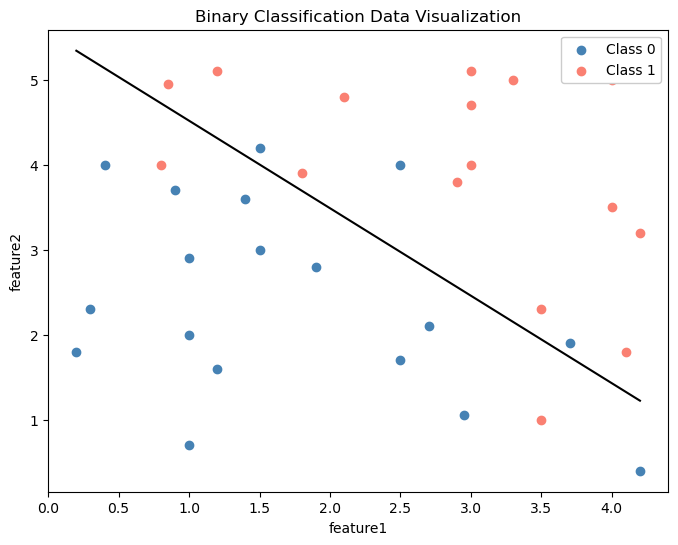

In [21]:
w_res_model_1 = [w[j].x for j in range(n_features)]
b_res_model_1 = b.x

boundary_feature1 = [min(point_feature[index][0] for index in point_index), max(point_feature[index][0] for index in point_index)]
boundary_feature2 = [-(w_res_model_1[0] * feature1 + b_res_model_1)/w_res_model_1[1] for feature1 in boundary_feature1]

plt.figure(figsize=(8, 6))
plt.plot(boundary_feature1, boundary_feature2, color='black')
plt.scatter([x[0] for x in point_class0], [x[1] for x in point_class0], c='steelblue', label='Class 0')
plt.scatter([x[0] for x in point_class1], [x[1] for x in point_class1], c='salmon', label='Class 1')

plt.xlabel("feature1")
plt.ylabel("feature2")
plt.title("Binary Classification Data Visualization")
plt.legend(loc='upper right', facecolor='white', framealpha=1.0)
plt.show()

## 问题二：指数锥模块求解
我们将原问题转化为带有指数锥约束的优化问题。
## 创建模型
创建名为`binary_classification_q2`的模型`model_2`。

In [23]:
env = cp.Envr()
model_2 = env.createModel("binary_classification_q2")

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



添加模型正则化参数`lamda`（即$\lambda$）和样本数量`n_samples`和样本特征数`n_features`。

In [25]:
lamda = 0
n_samples = len(point_index)
n_features = len(point_feature[1])

## 添加模型三要素

### 添加决策变量
添加决策变量 $\{w_j\}^{n\_features}_{j=1}$，$b$ 。

添加模型的辅助变量 $\{t_i\}^{n\_samples}_{i=1}$ 、$\{m_i\}^{n\_samples}_{i=1}$ 、$\{t\_minus_i\}^{n\_samples}_{i=1}$ 、$\{ones_i\}^{n\_samples}_{i=1}$ 、$\{u_i\}^{n\_samples}_{i=1}$ 、$\{v_i\}^{n\_samples}_{i=1}$ 、$r$ 。

其中对于 $\{ones_i\}^{n\_samples}_{i=1}$ 我们设置其上下界均为1来将其值设置为1。

In [27]:
w = model_2.addVars(n_features, lb=-COPT.INFINITY, ub=COPT.INFINITY, nameprefix="w")
b = model_2.addVar(lb=-COPT.INFINITY, ub=COPT.INFINITY, name="b")
t = model_2.addVars(point_index, lb=0, ub=COPT.INFINITY, nameprefix="t")
m = model_2.addVars(point_index, lb=-COPT.INFINITY, ub=COPT.INFINITY, nameprefix="m")
t_minus = model_2.addVars(point_index, lb=-COPT.INFINITY, ub=0, nameprefix="t")
ones = model_2.addVars(point_index, lb=1.0, ub=1.0)
u = model_2.addVars(point_index, lb=0, ub=1, nameprefix="u")
v = model_2.addVars(point_index, lb=0, ub=1, nameprefix="v")
r = model_2.addVar(lb=0, ub=COPT.INFINITY, name="r")

### 设置目标函数

目标函数为
$$
\min_{\mathbf{w}\in \mathbb{R}^2, b \in \mathbb{R}} \sum_{i=1}^n t_i + \lambda r
$$

In [29]:
obj_model_2 = cp.quicksum(t[index] for index in point_index) + lamda * r
model_2.setObjective(obj_model_2, COPT.MINIMIZE)

### 添加约束条件

**1. 线性约束**

\begin{aligned}
m_i &= \begin{cases}
-(\mathbf{w}^\top \mathbf{x}_i + b)-t_i,\ &\text{if } y_i = 1 \\
(\mathbf{w}^\top \mathbf{x}_i + b)-t_i,\ &\text{if } y_i = 0 \\
\end{cases}\ & i = 1,...,n;\\
-t_i &= t\_minus_i,& i = 1,...,n; \\
u_i + v_i &\leq 1,& i = 1,...,n; \\
\end{aligned}

In [31]:
model_2.addConstrs(m[index] == -(cp.quicksum(w[j] * point_feature[index][j] for j in range(n_features)) + b) - t[index] for index in point_index if point_class[index] == 1)
model_2.addConstrs(m[index] == (cp.quicksum(w[j] * point_feature[index][j] for j in range(n_features)) + b) - t[index] for index in point_index if point_class[index] == 0)
model_2.addConstrs(t_minus[index] == -t[index] for index in point_index)
model_2.addConstrs(u[index] + v[index] <= 1 for index in point_index)

**2. 指数锥约束**

我们在建模分析时，通过引入辅助变量 $ones$ 和 $t\_minus$ ，转化为标准的（由单个元素构成）的指数锥约束：

$$
\begin{aligned}
(u_i,ones_i,m_i) &\in K_{\text{exp}},& i = 1,...,n; \\
(v_i,ones_i,t\_minus_i) &\in K_{\text{exp}},& i = 1,...,n; \\
\end{aligned}
$$


In [33]:
for index in point_index:
    coneVars_1 = [u[index], ones[index], m[index]]
    model_2.addExpCone(coneVars_1, COPT.EXPCONE_PRIMAL)
    coneVars_2 = [v[index], ones[index], t_minus[index]]
    model_2.addExpCone(coneVars_2, COPT.EXPCONE_PRIMAL)

**3. 二次约束**
$$
r \geq \| \mathbf{w} \|_2^2
$$

In [35]:
model_2.addQConstr(r >= cp.quicksum(w[j]*w[j] for j in range(n_features)))

<coptpy.QConstraint: >

## 求解

In [37]:
model_2.solve()

Model fingerprint: 45cae69a

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing a CONIC problem

The original problem has:
    105 rows, 214 columns and 315 non-zero elements
    1 quadratic constraints
    70 exponential cones
The presolved problem has:
    110 rows, 254 columns and 325 non-zero elements
    1 cones
    70 exponential cones

Starting barrier solver using 4 CPU threads

Problem info:
    Range of matrix coefficients:    [5e-02,1e+00]
    Range of rhs coefficients:       [5e-01,1e+00]
    Range of bound coefficients:     [4e-01,1e+00]
    Range of cost coefficients:      [1e+00,1e+00]

Factor info:
    Number of dense columns:         0
    Number of matrix entries:        8.880e+02
    Number of factor entries:        8.880e+02
    Number of factor flops:          1.842e+04

Iter       Primal.Ob

## 获取结果

In [39]:
if model_2.status == COPT.OPTIMAL:
  print("\nOptimal objective value:")
  print(" {0:.3e}".format(model_2.objval))

  print("\nVariable solution:")
  vars_model_2 = model_2.getVars()
  for var in vars_model_2:
      if var.name.startswith("w") or var.name.startswith("b"):
        print(" {0} = {1:.3e}".format(var.name, var.x))
else:
  print("\n No solution available")


Optimal objective value:
 1.117e+01

Variable solution:
 w(0) = 1.870e+00
 w(1) = 1.818e+00
 b = -1.008e+01


我们求解问题二，也得到了数据分类模型的参数 $\mathbf{w}$ 和 $b$ ，我们用同样的方法绘制出这条分类边界。

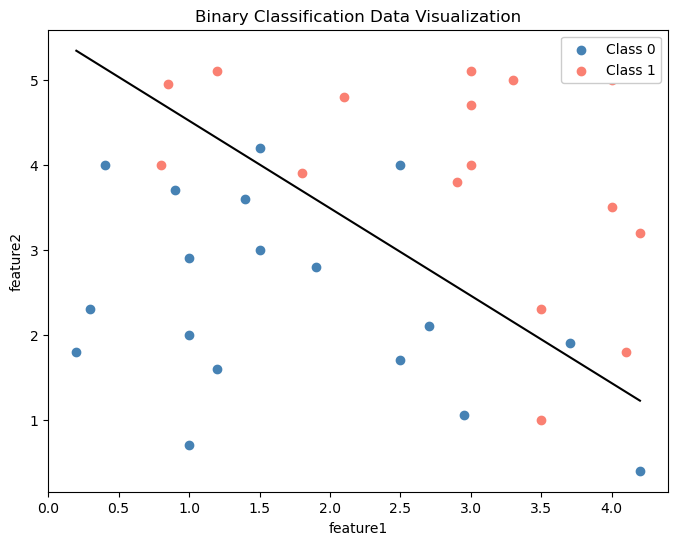

In [41]:
w_res_model_2 = [w[j].x for j in range(n_features)]
b_res_model_2 = b.x

boundary_feature1 = [min(point_feature[index][0] for index in point_index), max(point_feature[index][0] for index in point_index)]
boundary_feature2 = [-(w_res_model_2[0] * feature1 + b_res_model_2)/w_res_model_2[1] for feature1 in boundary_feature1]

plt.figure(figsize=(8, 6))
plt.plot(boundary_feature1, boundary_feature2, color='black')
plt.scatter([x[0] for x in point_class0], [x[1] for x in point_class0], c='steelblue', label='Class 0')
plt.scatter([x[0] for x in point_class1], [x[1] for x in point_class1], c='salmon', label='Class 1')

plt.xlabel("feature1")
plt.ylabel("feature2")
plt.title("Binary Classification Data Visualization")
plt.legend(loc='upper right', facecolor='white', framealpha=1.0)
plt.show()

# 案例拓展：使用非线性分类边界进行二维数据分类代码实现

假设我们有如下一组样本数据及对应的类别标签，可以观察到这些数据的分类边界很有可能是非线性的，此时再用线性边界的数据分类器将无法得到很好的预测效果，下面的代码可以模拟出一个非线性的分类边界，让我们的数据分类器可以更加灵活地预测数据的分类。

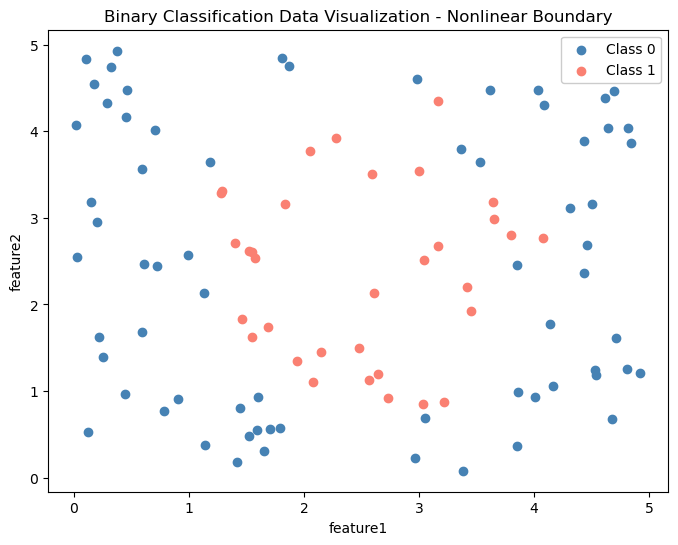

In [43]:
# point: [[feature1, feature2], class]
point_data = {
    1: [[1.87, 4.75], 0], 2: [[3.65, 2.99], 1], 3: [[0.78, 0.77], 0], 4: [[0.29, 4.33], 0], 5: [[3.0, 3.54], 1], 6: [[0.1, 4.84], 0], 7: [[4.16, 1.06], 0], 8: [[0.9, 0.91], 0], 9: [[1.52, 2.62], 1], 10: [[2.15, 1.45], 1], 11: [[3.05, 0.69], 0], 12: [[1.46, 1.83], 1], 13: [[2.28, 3.92], 1], 14: [[0.99, 2.57], 0], 15: [[2.96, 0.23], 0], 16: [[3.03, 0.85], 1], 17: [[0.32, 4.74], 0], 18: [[4.82, 4.04], 0], 19: [[1.52, 0.48], 0], 20: [[3.42, 2.2], 1], 21: [[0.61, 2.47], 0], 22: [[0.17, 4.54], 0], 23: [[1.29, 3.31], 1], 24: [[1.55, 2.6], 1], 25: [[2.73, 0.92], 1], 26: [[4.84, 3.87], 0], 27: [[4.69, 4.47], 0], 28: [[2.98, 4.6], 0], 29: [[0.44, 0.97], 0], 30: [[0.22, 1.62], 0], 31: [[1.94, 1.35], 1], 32: [[4.14, 1.78], 0], 33: [[1.4, 2.71], 1], 34: [[0.7, 4.01], 0], 35: [[0.37, 4.93], 0], 36: [[3.86, 0.99], 0], 37: [[0.02, 4.07], 0], 38: [[3.53, 3.64], 0], 39: [[3.85, 0.37], 0], 40: [[1.79, 0.57], 0], 41: [[4.31, 3.11], 0], 42: [[1.65, 0.31], 0], 43: [[1.55, 1.62], 1], 44: [[3.64, 3.18], 1], 45: [[4.43, 2.36], 0], 46: [[0.59, 3.56], 0], 47: [[3.8, 2.8], 1], 48: [[3.85, 2.46], 0], 49: [[2.61, 2.13], 1], 50: [[0.12, 0.53], 0], 51: [[0.15, 3.18], 0], 52: [[1.57, 2.54], 1], 53: [[4.53, 1.24], 0], 54: [[2.05, 3.77], 1], 55: [[1.14, 0.38], 0], 56: [[1.44, 0.8], 0], 57: [[4.64, 4.04], 0], 58: [[3.16, 4.35], 1], 59: [[4.01, 0.93], 0], 60: [[4.46, 2.69], 0], 61: [[4.03, 4.48], 0], 62: [[1.59, 0.55], 0], 63: [[1.13, 2.13], 0], 64: [[4.09, 4.3], 0], 65: [[0.03, 2.55], 0], 66: [[2.08, 1.11], 1], 67: [[0.59, 1.68], 0], 68: [[4.71, 1.61], 0], 69: [[2.59, 3.51], 1], 70: [[1.81, 4.85], 0], 71: [[4.81, 1.25], 0], 72: [[2.48, 1.5], 1], 73: [[1.42, 0.18], 0], 74: [[3.04, 2.51], 1], 75: [[0.25, 1.39], 0], 76: [[4.54, 1.19], 0], 77: [[0.72, 2.44], 0], 78: [[4.92, 1.21], 0], 79: [[3.36, 3.8], 0], 80: [[1.18, 3.64], 0], 81: [[1.83, 3.16], 1], 82: [[3.16, 2.67], 1], 83: [[0.45, 4.17], 0], 84: [[1.6, 0.93], 0], 85: [[0.2, 2.95], 0], 86: [[3.38, 0.08], 0], 87: [[2.56, 1.13], 1], 88: [[3.22, 0.87], 1], 89: [[3.45, 1.93], 1], 90: [[4.68, 0.68], 0], 91: [[1.7, 0.56], 0], 92: [[4.62, 4.38], 0], 93: [[1.28, 3.29], 1], 94: [[4.08, 2.77], 1], 95: [[2.64, 1.2], 1], 96: [[0.46, 4.48], 0], 97: [[4.5, 3.16], 0], 98: [[1.69, 1.74], 1], 99: [[3.62, 4.48], 0], 100: [[4.43, 3.89], 0]
}

point_index, point_feature, point_class = cp.multidict(point_data)

import matplotlib.pyplot as plt

point_class0 = [point_feature[index] for index in point_index if point_class[index] == 0]  # 类别 0
point_class1 = [point_feature[index] for index in point_index if point_class[index] == 1]  # 类别 1

plt.figure(figsize=(8, 6))
plt.scatter([x[0] for x in point_class0], [x[1] for x in point_class0], c='steelblue', label='Class 0')
plt.scatter([x[0] for x in point_class1], [x[1] for x in point_class1], c='salmon', label='Class 1')

plt.xlabel('feature1')
plt.ylabel('feature2')
plt.title('Binary Classification Data Visualization - Nonlinear Boundary')
plt.legend(loc='upper right', facecolor='white', framealpha=1.0)
plt.show()

In [45]:
env = cp.Envr()
model_3 = env.createModel("binary_classification_q3")
model_3.matrixmodelmode = "experimental"

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



在`model_2`中添加矩阵 $ \mathbf{A} $ 相关的决策变量，注意矩阵 $ \mathbf{A} $ 是对称矩阵，需要添加对称矩阵约束；将关于决策变量 $m_i$ 的等式约束中 $(\mathbf{w}^\top \mathbf{x}_i + b)$ 转变为新的非线性形式 $(\mathbf{x}_i^\top \mathbf{A} \mathbf{x}_i + \mathbf{w}^\top \mathbf{x}_i + b)$，并将与模型正则化有关的决策变量 $r$ 的约束改为 $r \geq \| \mathbf{A} \|^2_F + \| \mathbf{w} \|_2^2$ ，其中 $\| \mathbf{A} \|^2_F = \sum_{i=1}^{m} \sum_{j=1}^{n} A_{ij}^2$。

创建名为`binary_classification_q3`的模型`model_3`，并依照`model_2`的形式配置好模型参数和三要素，求解并使结果可视化。

In [47]:
lamda = 0
n_samples = len(point_index)
n_features = len(point_feature[1])

In [49]:
# 增加2*2矩阵决策变量 A
A = model_3.addMVar(shape=(n_features,n_features), lb=-COPT.INFINITY, ub=COPT.INFINITY, nameprefix="A")
w = model_3.addVars(n_features, lb=-COPT.INFINITY, ub=COPT.INFINITY, nameprefix="w")
b = model_3.addVar(lb=-COPT.INFINITY, ub=COPT.INFINITY, name="b")
t = model_3.addVars(point_index, lb=0, ub=COPT.INFINITY, nameprefix="t")
u = model_3.addVars(point_index, lb=0, ub=1, nameprefix="u")
v = model_3.addVars(point_index, lb=0, ub=1, nameprefix="v")
r = model_3.addVar(lb=0, ub=COPT.INFINITY, name="r")

In [51]:
obj_model_3 = cp.quicksum(t[index] for index in point_index) + lamda * r
model_3.setObjective(obj_model_3, COPT.MINIMIZE)

<font color=#0000FF>
<b>提示：使用COPT的矩阵建模功能</b>
</font>

目前COPT支持添加MVar类到模型运算中，MVar类是杉数求解器中用于构建多维变量，并支持NumPy的多维数组运算的类。 我们建议通过`Model`类的方法`addVars`或者`addMVar`构建，其输入参量详细说明可参考[《COPT用户手册：Python API》](https://guide.coap.online/copt/zh-doc/pyapiref.html)


In [53]:
# 添加对称矩阵约束
model_3.addConstrs(A[i, j].item() == A[j, i].item() for i in range(n_features) for j in range(i + 1, n_features))

# 添加惩罚项相关的二次约束
quad_expr = cp.QuadExpr()
quad_expr.addTerms([1.0]*n_features, w.values(), w.values())

for i in range(n_features):
    for j in range(n_features):
        quad_expr.addTerm(1.0, A[i, j].item(), A[i, j].item())

model_3.addQConstr(r >= quad_expr)

<coptpy.QConstraint: >

<font color=#0000FF>
<b>提示：使用COPT的 LinExpr、QuadExpr 等方法构造相关表达式</b>
</font>

 COPT支持使用多种方法构造表达式，在表达式形式较为简单时，我们可以直接使用相加`+`或者求和`quicksum()`来构造表达式；但是当表达式形式较为复杂尤其是存在二次项的加和时，直接使用累加容易出现参数输入错误，故推荐使用更加标准的表达式构建方法。

- `LinExpr.addTerm(var, coeff=1.0)`：添加单个新的项到当前线性表达式中，其中`var`是待添加项的变量，`coeff`是待添加项的放大系数，可选参量，默认值为`1.0`。
- `LinExpr.addTerms(vars, coeffs)`：添加单个或多个项到当前线性表达式中，其中`vars`是待添加项的变量，`coeffs`是待添加项的放大系数。注意`vars`和`coeffs`的类型需要对应，如都为`list`类对象或`tupledict`类对象。
- `QuadExpr.addTerm(coeff, var1, var2=None)`：添加单个新的项到当前二次表达式中，其中`coeff`是待添加项的系数，`var1`是待添加项的第一个变量，`var2`是待添加项的第二个变量，可以为`None`表示添加线性项。
- `QuadExpr.addTerms(coeffs, vars1, vars2=None)`：添加单个或多个新的项到当前二次表达式中，其中`coeffs`是待添加项的系数，`vars1`是待添加项的第一个变量，`vars2`是待添加项的第二个变量，可以为`None`表示添加线性项。注意`vars`和`coeffs`的类型需要对应，如都为`list`类对象或`tupledict`类对象。

在本案例中，`A`是我们创建的`MVar`类变量，取出的`A[i, j]`也是一个0维的`MVar`类变量，在使用`addTerm()`时需要将0维的`MVar`类变量使用`MVar.item()`转化成`Var`类变量；
`w`是我们创建的`tupledict`类变量，但我们的`point_feature[index]`是一个`list`类对象，在使用`addTerms()`时需要将`tupledict`类变量使用`tupledict.values()`转化成`list`类对象。

针对 LinExpr、QuadExpr 等各类表达式构建方法具体参数输入说明请参考[《COPT用户手册》：Python API](https://www.shanshu.ai/copt-document/manual?id=19&docType=3)。

在非线性的分类边界下，如下是原始的仿射形式的指数约束：

$$
z(\mathbf{x}) = \mathbf{x}^\top \mathbf{A} \mathbf{x} + \mathbf{w}^\top \mathbf{x} + b
$$

$$
t_i \geq \log(1+e^{-z(\mathbf{x})}) 
\ \Longleftrightarrow \quad
\begin{cases}
u_i + v_i \leq 1 \\
(u_i,1,-z(\mathbf{x})-t_i) \in K_{\text{exp}} \\
(v_i,1,-t_i) \in K_{\text{exp}}
\end{cases}\ , \text{if } y_i = 1\\
$$

$$
t_i \geq \log(1+e^{z(\mathbf{x})}) 
\ \Longleftrightarrow\quad
\begin{cases}
u_i + v_i \leq 1 \\
(u_i,1,z(\mathbf{x})-t_i) \in K_{\text{exp}} \\
(v_i,1,-t_i) \in K_{\text{exp}}
\end{cases}\ , \text{if } y_i = 0\\
$$

自COPT 7.2.4起，**COPT新增了对于仿射锥建模的支持，便于用户对复杂的锥约束进行建模。构成锥的元素可以为线性表达式或者常数，无需再通过增加辅助变量进行标准型转化**。因此，这里我们展示直接添加仿射形式的指数锥约束的方式，可以有效控制问题变量规模，并且建模友好，与上述的代数形式十分接近。

In [55]:
# 添加指数锥约束：不通过辅助变量，直接构建仿射锥
for index in point_index:
    # 构造非线性边界的表达式z(x)
    lin_expr = cp.LinExpr()
    for i in range(n_features):
        for j in range(n_features):
            lin_expr.addTerm(A[i, j].item(), point_feature[index][i] * point_feature[index][j])
    lin_expr.addTerms(w.values(), point_feature[index])
    lin_expr.addTerm(b)

    model_3.addConstr(u[index] + v[index] <= 1)

    # 添加指数锥约束 方法一：不通过辅助变量，直接构建仿射锥
    afcone_1 = cp.AffineConeBuilder()
    afcone_2 = cp.AffineConeBuilder()
    if point_class[index] == 1:
        afcone_1.setBuilder(COPT.EXPCONE_PRIMAL, [u[index], 1, - lin_expr - t[index]])
    else:
        afcone_1.setBuilder(COPT.EXPCONE_PRIMAL, [u[index], 1, lin_expr - t[index]])
    afcone_2.setBuilder(COPT.EXPCONE_PRIMAL, [v[index], 1, - t[index]])
    model_3.addAffineCone(afcone_1)
    model_3.addAffineCone(afcone_2)

<font color=#0000FF>
<b>提示：使用COPT的 AffineConeBuilder 类方法、Model.addAffineCone() 构造仿射锥并添加约束</b>
</font>

AffineConeBuilder类方法是COPT中构建仿射锥约束的构建器的封装，使用其成员方法我们可以无需添加辅助变量，将表达式直接写入仿射锥。

- `AffineConeBuilder()`：创建一个空的`AffineConeBuilder`类对象。。
- `AffineConeBuilder.setBuilder(conetype, exprs)`：设置仿射锥，其中`conetype`是仿射锥类型，我们此处设置为`COPT.EXPCONE_PRIMAL`，`exprs`为构成仿射锥的数学表达式，可取值为线性表达式或半定表达式。
- `Model.addAffineCone(exprs, ctype=None, name="")`：添加一个仿射锥到模型中，其中参数`exprs`是仿射锥生成器或构成仿射锥的多维数组表达式，参数`ctype`是仿射锥的类型。若参数`exprs`是`AffineConeBuilder`类对象，则参数`ctype`的值将被忽略。

针对 AffineConeBuilder 类方法、Model.addAffineCone() 构造仿射锥的其他成员方法及具体参数输入说明请参考[《COPT用户手册》：Python API](https://www.shanshu.ai/copt-document/manual?id=19&docType=3)。

当然，我们依然可以通过构造辅助变量，先将其转换为标准形式的指数锥，再通过 ``Model.addExpCone()`` 建模输入，代码实现如下所示：

In [57]:
# # 添加指数锥约束 方法二：通过辅助变量 m 和 t_minus 构建标准的指数锥
# m = model_3.addVars(point_index, lb=-COPT.INFINITY, ub=COPT.INFINITY, nameprefix="m")
# t_minus = model_3.addVars(point_index, lb=-COPT.INFINITY, ub=0, nameprefix="t")
# ones = model_3.addVars(point_index, lb=1.0, ub=1.0)
# model_3.addConstr(t_minus[index] == -t[index])
# if point_class[index] == 1:
#     model_3.addConstr(m[index] == - lin_expr - t[index])
# else:
#     model_3.addConstr(m[index] == lin_expr - t[index])
# coneVars_1 = [u[index], ones[index], m[index]]
# model_3.addExpCone(coneVars_1, COPT.EXPCONE_PRIMAL)
# coneVars_2 = [v[index], ones[index], t_minus[index]]
# model_3.addExpCone(coneVars_2, COPT.EXPCONE_PRIMAL)

In [59]:
model_3.solve()

Model fingerprint: 65066b0b

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing a CONIC problem

The original problem has:
    101 rows, 308 columns and 202 non-zero elements
    1 quadratic constraints
    200 affine cones
The presolved problem has:
    310 rows, 717 columns and 1320 non-zero elements
    1 cones
    200 exponential cones

Starting barrier solver using 4 CPU threads

Problem info:
    Range of matrix coefficients:    [3e-05,1e+00]
    Range of rhs coefficients:       [5e-01,1e+00]
    Range of bound coefficients:     [4e-01,1e+00]
    Range of cost coefficients:      [1e+00,1e+00]

Factor info:
    Number of dense columns:         0
    Number of matrix entries:        6.296e+03
    Number of factor entries:        6.498e+03
    Number of factor flops:          4.389e+05

Iter       Primal.Obj 

In [61]:
if model_3.status == COPT.OPTIMAL:
  print("\nOptimal objective value:")
  print(" {0:.3e}".format(model_3.objval))

  print("\nVariable solution:")
  vars_model_3 = model_3.getVars()
  for var in vars_model_3:
      if var.name.startswith("A") or var.name.startswith("w") or var.name.startswith("b"):
        print(" {0} = {1:.3e}".format(var.name, var.x))
else:
  print("\n No solution available")


Optimal objective value:
 1.221e+01

Variable solution:
 A(0,0) = -4.373e+00
 A(0,1) = -3.688e-01
 A(1,0) = -3.688e-01
 A(1,1) = -2.346e+00
 w(0) = 2.407e+01
 w(1) = 1.385e+01
 b = -3.954e+01


下面我们将求解结果得到的非线性分类边界绘制出来。

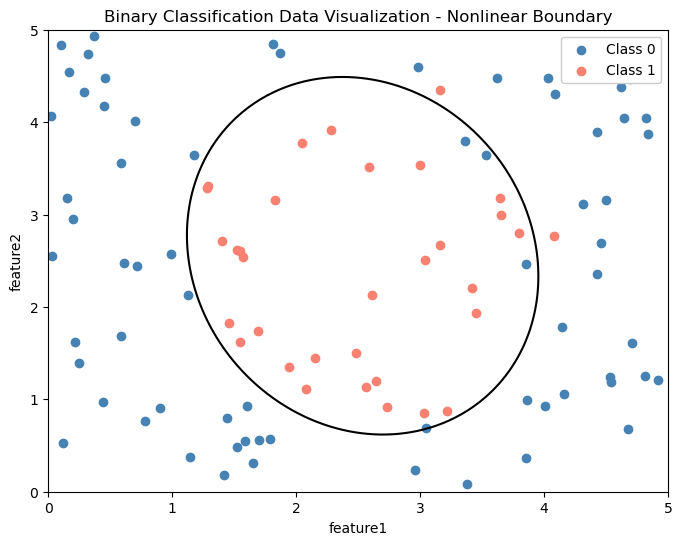

In [64]:
import numpy as np
import matplotlib.pyplot as plt

A_res_model_3 = np.array([[A[i, j].x for i in range(n_features)] for j in range(n_features)])
w_res_model_3 = np.array([w[j].x for j in range(n_features)])
b_res_model_3 = b.x

def quadratic_curve(x, A, w, b):
    return x.T @ A @ x + w.T @ x + b

feature1 = np.linspace(0, 5, 100)
feature2 = np.linspace(0, 5, 100)
F1, F2 = np.meshgrid(feature1, feature2)

Z = np.zeros_like(F1)
for i in range(F1.shape[0]):
    for j in range(F1.shape[1]):
        x = np.array([F1[i, j], F2[i, j]])
        Z[i, j] = quadratic_curve(x, A_res_model_3, w_res_model_3, b_res_model_3)

plt.figure(figsize=(8, 6))
contour = plt.contour(F1, F2, Z, levels=[0], colors='black')
plt.scatter([x[0] for x in point_class0], [x[1] for x in point_class0], c='steelblue', label='Class 0')
plt.scatter([x[0] for x in point_class1], [x[1] for x in point_class1], c='salmon', label='Class 1')
plt.xlabel('feature1')
plt.ylabel('feature2')
plt.title("Binary Classification Data Visualization - Nonlinear Boundary")
plt.legend(loc='upper right', facecolor='white', framealpha=1.0)
plt.show()
